# Знакомство с PM4Py

PM4Py помогает изучать процессы по журналам событий. Например, по истории заявок
можно узнать, какие шаги они проходят, где задерживаются и когда уходят с обычного маршрута.

В этом ноутбуке предстоит создать небольшой журнал, построить модель обработки заявок
и проверить, соответствуют ли ей новые трассы. Данные уже включены в пример.

Для этого потребуется разобраться с подготовкой таблицы, вариантами трасс, фильтрацией,
графом переходов, сетью Петри и обменом данными через XES. Перед каждым примером с PM4Py отдельно
указана нужная функция: что ей передать и что получится на выходе.
В конце есть справочник всех использованных функций PM4Py.

## Как устроена работа с процессом

В этом примере предстоит пройти четыре шага: подготовить журнал, изучить данные,
построить модель и проверить по ней трассы. Два последних шага называют
**discovery** и **conformance checking**. Это разные задачи process mining,
которые здесь удобно выполнять последовательно.

| Шаг | Что нужно узнать | Входные данные | Результат |
|---|---|---|---|
| Подготовка | Можно ли восстановить порядок событий? | Исходную таблицу | Журнал с кейсами, действиями и временем |
| Анализ журнала | Какие маршруты встречаются и сколько занимают? | Журнал | Частоты, варианты трасс и длительности |
| Discovery | Какую модель можно построить по наблюдениям? | Журнал без готовой модели | DFG или сеть Петри |
| Conformance checking | Соответствуют ли наблюдения выбранной модели? | Журнал и готовую модель | Оценку соответствия и диагностику отклонений |

**Discovery** строит модель по данным. Например, если после проверки заявка
иногда возвращается на доработку, алгоритм может отразить это циклом в сети.

**Conformance checking** сравнивает поведение с уже заданной моделью.
Например, проверяет, разрешено ли одобрение без предварительной проверки.
Модель можно получить через discovery или задать вручную по регламенту.
Поэтому перед conformance checking не обязательно каждый раз выполнять discovery.

В process mining также выделяют **enhancement**, дополнение или улучшение существующей
модели по данным. Например, на её рёбра можно нанести время ожидания.
В этом примере достаточно проанализировать временные интервалы в DFG.

## 1. Окружение

Нужны библиотеки pm4py, pandas, matplotlib, graphviz

In [16]:
# Раскомментируйте при первом запуске, если зависимости ещё не установлены:
# %pip install "pm4py>=2.7,<3" pandas matplotlib graphviz

In [17]:
import shutil
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import pandas as pd
import pm4py
from IPython.display import SVG, display

HAS_DOT = shutil.which("dot") is not None
print("PM4Py:", pm4py.__version__)
print("pandas:", pd.__version__)
print("Graphviz dot доступен:", HAS_DOT)

PM4Py: 2.7.23.8
pandas: 2.3.3
Graphviz dot доступен: True


## 2. Что такое журнал событий

Каждая строка журнала описывает **событие**, например проверку заявки.
Все события одной заявки образуют **кейс** (case).
Если расположить их по времени, получится **трасса**.

Две заявки могут пройти одни и те же шаги в разное время.
Тогда у них одинаковый **вариант трассы**: последовательность названий действий
без дат и номера заявки.

Для работы нужны три поля:

| Исходный столбец | Что хранит | Стандартное имя в PM4Py / XES |
|---|---|---|
| `case_id` | Идентификатор заявки | `case:concept:name` |
| `activity` | Название действия | `concept:name` |
| `timestamp` | Время события | `time:timestamp` |

Для примера нужно создать восемь завершённых заявок: четыре обычные, две с доработкой и две отклонённые.
Числа в списках показывают, через сколько часов после открытия заявки произошло событие.
Времена фиксированы, поэтому при повторном запуске данные будут теми же.

In [18]:
normal = ["Создать", "Проверить", "Одобрить", "Закрыть"]
rework = ["Создать", "Проверить", "Доработать", "Проверить", "Одобрить", "Закрыть"]
rejected = ["Создать", "Проверить", "Отклонить", "Закрыть"]

cases = [
    ("C01", normal,   [0, 1, 3, 5]),
    ("C02", normal,   [0, 2, 4, 7]),
    ("C03", normal,   [0, 1, 2, 4]),
    ("C04", normal,   [0, 3, 5, 8]),
    ("C05", rework,   [0, 1, 4, 6, 7, 9]),
    ("C06", rework,   [0, 2, 5, 8, 9, 12]),
    ("C07", rejected, [0, 1, 2, 3]),
    ("C08", rejected, [0, 2, 3, 5]),
]

rows = []
base_time = pd.Timestamp("2026-01-01 09:00:00", tz="UTC")
for day, (case_id, activities, hours) in enumerate(cases):
    case_start = base_time + pd.Timedelta(days=day)
    for activity, hour in zip(activities, hours):
        rows.append({
            "case_id": case_id,
            "activity": activity,
            "timestamp": case_start + pd.Timedelta(hours=hour),
        })

raw = pd.DataFrame(rows)
assert len(raw) == 36 and raw["case_id"].nunique() == 8
raw.head(10)

,case_id,activity,timestamp
0,C01,Создать,2026-01-01 09:00:00+00:00
1,C01,Проверить,2026-01-01 10:00:00+00:00
2,C01,Одобрить,2026-01-01 12:00:00+00:00
3,C01,Закрыть,2026-01-01 14:00:00+00:00
4,C02,Создать,2026-01-02 09:00:00+00:00
5,C02,Проверить,2026-01-02 11:00:00+00:00
6,C02,Одобрить,2026-01-02 13:00:00+00:00
7,C02,Закрыть,2026-01-02 16:00:00+00:00
8,C03,Создать,2026-01-03 09:00:00+00:00
9,C03,Проверить,2026-01-03 10:00:00+00:00


### Подготовка таблицы для PM4Py

**Функция: `pm4py.format_dataframe`**

```python
pm4py.format_dataframe(raw, case_id="case_id", activity_key="activity", timestamp_key="timestamp")
```

Принимает таблицу событий и названия трёх основных столбцов.
Возвращает DataFrame со стандартными полями PM4Py, включая `case:concept:name`,
`concept:name` и `time:timestamp`. Дальше функции смогут использовать эти поля
без повторного указания исходных названий.

Перед вызовом нужно проверить пропуски, привести время к UTC и отсортировать события.
Для реальных данных нужно знать исходный часовой пояс.
Если у двух событий одной заявки одинаковое время, понадобится дополнительный
признак порядка, например номер события из исходной системы.

In [19]:
assert not raw[["case_id", "activity", "timestamp"]].isna().any().any() #проверка что нет пропусков
raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
raw = raw.sort_values(["case_id", "timestamp"], kind="stable").reset_index(drop=True)

log = pm4py.format_dataframe(
    raw.copy(),
    case_id="case_id",
    activity_key="activity",
    timestamp_key="timestamp",
)

CASE = "case:concept:name"
ACTIVITY = "concept:name"
TIME = "time:timestamp"
display(log[[CASE, ACTIVITY, TIME]].head(10))

,case:concept:name,concept:name,time:timestamp
0,C01,Создать,2026-01-01 09:00:00+00:00
1,C01,Проверить,2026-01-01 10:00:00+00:00
2,C01,Одобрить,2026-01-01 12:00:00+00:00
3,C01,Закрыть,2026-01-01 14:00:00+00:00
4,C02,Создать,2026-01-02 09:00:00+00:00
5,C02,Проверить,2026-01-02 11:00:00+00:00
6,C02,Одобрить,2026-01-02 13:00:00+00:00
7,C02,Закрыть,2026-01-02 16:00:00+00:00
8,C03,Создать,2026-01-03 09:00:00+00:00
9,C03,Проверить,2026-01-03 10:00:00+00:00


## 3. Первое знакомство с процессом

Сначала нужно посчитать заявки и события, затем определить, с чего процесс начинается и чем заканчивается.
В заявке с доработкой проверка встречается дважды, поэтому частота действия
может быть больше числа заявок.

**Функция: `pm4py.get_start_activities`**

```python
pm4py.get_start_activities(log)
```

Принимает журнал и возвращает словарь: название первого действия и число кейсов,
которые с него начинаются. В этом примере должно получиться `{"Создать": 8}`.

**Функция: `pm4py.get_end_activities`**

```python
pm4py.get_end_activities(log)
```

Возвращает такой же словарь для последних действий. Здесь должно получиться `{"Закрыть": 8}`.
В реальном журнале последнее записанное действие не всегда означает завершение процесса.

In [20]:
print("Событий:", len(log))
print("Кейсов:", log[CASE].nunique())
print("Различных действий:", log[ACTIVITY].nunique())
print("Начальные действия:", pm4py.get_start_activities(log))
print("Конечные действия:", pm4py.get_end_activities(log))

activity_counts = log[ACTIVITY].value_counts().rename_axis("Действие").to_frame("Событий")
display(activity_counts)

Событий: 36
Кейсов: 8
Различных действий: 6
Начальные действия: {'Создать': 8}
Конечные действия: {'Закрыть': 8}


,Событий
Действие,
Проверить,10
Создать,8
Закрыть,8
Одобрить,6
Доработать,2
Отклонить,2


### Варианты трасс

**Функция: `pm4py.get_variants_as_tuples`**

```python
pm4py.get_variants_as_tuples(log)
```

Принимает журнал и возвращает словарь. Ключом служит кортеж действий,
например `("Создать", "Проверить", "Одобрить", "Закрыть")`.
Значение показывает, сколько кейсов прошло этот маршрут.

В исходных данных три варианта с частотами 4, 2 и 2. Для удобства можно преобразовать
словарь в таблицу и добавить долю каждого варианта. Самый частый маршрут описывает привычное поведение,
но не обязательно соответствует регламенту.

In [21]:
variants = pm4py.get_variants_as_tuples(log)
variants_table = pd.DataFrame([
    {"Вариант": " → ".join(variant), "Кейсов": count}
    for variant, count in variants.items()
]).sort_values("Кейсов", ascending=False).reset_index(drop=True)
variants_table["Доля"] = variants_table["Кейсов"] / log[CASE].nunique()
assert sorted(variants.values()) == [2, 2, 4]
variants_table

,Вариант,Кейсов,Доля
0,Создать → Проверить → Одобрить → Закрыть,4,0.50
1,Создать → Проверить → Доработать → Проверить →...,2,0.25
2,Создать → Проверить → Отклонить → Закрыть,2,0.25


### Длительность кейсов

Нужно посчитать, сколько времени прошло от первого до последнего события каждой заявки.
Для этого достаточно средствами pandas сгруппировать строки по кейсу, найти крайние даты
и вычесть одну из другой.

Полученная длительность включает ожидание. По этим данным нельзя отдельно узнать,
сколько времени сотрудники работали над заявкой: в журнале нет отметок начала
и завершения каждого действия.

,started,finished,events,duration_hours
case:concept:name,,,,
C01,2026-01-01 09:00:00+00:00,2026-01-01 14:00:00+00:00,4,5.0
C02,2026-01-02 09:00:00+00:00,2026-01-02 16:00:00+00:00,4,7.0
C03,2026-01-03 09:00:00+00:00,2026-01-03 13:00:00+00:00,4,4.0
C04,2026-01-04 09:00:00+00:00,2026-01-04 17:00:00+00:00,4,8.0
C05,2026-01-05 09:00:00+00:00,2026-01-05 18:00:00+00:00,6,9.0
C06,2026-01-06 09:00:00+00:00,2026-01-06 21:00:00+00:00,6,12.0
C07,2026-01-07 09:00:00+00:00,2026-01-07 12:00:00+00:00,4,3.0
C08,2026-01-08 09:00:00+00:00,2026-01-08 14:00:00+00:00,4,5.0


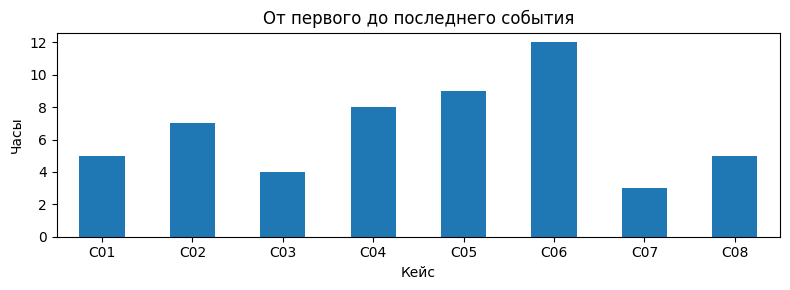

In [22]:
case_stats = log.groupby(CASE).agg(
    started=(TIME, "min"),
    finished=(TIME, "max"),
    events=(ACTIVITY, "size"),
)
case_stats["duration_hours"] = (
    case_stats["finished"] - case_stats["started"]
).dt.total_seconds() / 3600

display(case_stats)
ax = case_stats["duration_hours"].plot.bar(figsize=(8, 3), rot=0)
ax.set(xlabel="Кейс", ylabel="Часы", title="От первого до последнего события")
plt.tight_layout()
plt.show()

## 4. Фильтрация: выбор заявок с доработкой

**Функция: `pm4py.filter_event_attribute_values`**

```python
pm4py.filter_event_attribute_values(log, ACTIVITY, ["Доработать"], level="case", retain=True)
```

Принимает журнал, название атрибута и список значений для поиска.
Здесь нужно найти действие «Доработать» в столбце `concept:name`.

- `level="case"` сохраняет все события кейсов, где встретилось нужное действие.
- `level="event"` оставляет только сами подходящие события.
- `retain=True` оставляет совпадения, а `retain=False` исключает их на выбранном уровне.

Функция вернёт отфильтрованный журнал. Чтобы сохранить весь путь заявки,
нужно выбрать уровень кейсов. Должны остаться две заявки и 12 событий.

In [23]:
rework_log = pm4py.filter_event_attribute_values(
    log,
    ACTIVITY,
    ["Доработать"],
    level="case",
    retain=True,
)
print("Кейсов с доработкой:", rework_log[CASE].nunique())
print("Событий в этих кейсах:", len(rework_log))
assert rework_log[CASE].nunique() == 2 and len(rework_log) == 12
rework_log[[CASE, ACTIVITY, TIME]]

Кейсов с доработкой: 2
Событий в этих кейсах: 12


,case:concept:name,concept:name,time:timestamp
16,C05,Создать,2026-01-05 09:00:00+00:00
17,C05,Проверить,2026-01-05 10:00:00+00:00
18,C05,Доработать,2026-01-05 13:00:00+00:00
19,C05,Проверить,2026-01-05 15:00:00+00:00
20,C05,Одобрить,2026-01-05 16:00:00+00:00
21,C05,Закрыть,2026-01-05 18:00:00+00:00
22,C06,Создать,2026-01-06 09:00:00+00:00
23,C06,Проверить,2026-01-06 11:00:00+00:00
24,C06,Доработать,2026-01-06 14:00:00+00:00
25,C06,Проверить,2026-01-06 17:00:00+00:00


## 5. Discovery: построение графа непосредственного следования

Для начала удобно представить процесс в виде графа непосредственного следования, Directly-Follows Graph (DFG).
Его узлы обозначают действия. Ребро `A → B` появляется, если в какой-то трассе
сразу после `A` было выполнено `B`. Вес ребра показывает число таких пар событий.

**Функция: `pm4py.discover_dfg`**

```python
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
```

Принимает журнал и возвращает три словаря:

- `dfg`: пары действий и частоты непосредственного следования;
- `start_activities`: первые действия кейсов и их частоты;
- `end_activities`: последние действия кейсов и их частоты.

Сначала можно вывести рёбра таблицей. По ним удобно увидеть основные пути,
но DFG не хранит всю историю каждой трассы. Наличие ребра также не доказывает,
что одно действие стало причиной другого.

In [24]:
dfg, start_activities, end_activities = pm4py.discover_dfg(log)
dfg_table = pd.DataFrame([
    {"Из": source, "В": target, "Частота": count}
    for (source, target), count in dfg.items()
]).sort_values("Частота", ascending=False).reset_index(drop=True)
dfg_table

,Из,В,Частота
0,Создать,Проверить,8
1,Одобрить,Закрыть,6
2,Проверить,Одобрить,6
3,Доработать,Проверить,2
4,Отклонить,Закрыть,2
5,Проверить,Доработать,2
6,Проверить,Отклонить,2


### Визуализация DFG

**Функция: `dfg_visualizer.apply`**

```python
dfg_visualizer.apply(dfg, parameters={"start_activities": start_activities, "end_activities": end_activities})
```

Это `apply` из модуля `pm4py.visualization.dfg.visualizer`. Для вызова нужно импортировать
этот модуль под именем `dfg_visualizer`. Функция принимает готовый DFG и параметры отображения,
возвращает объект Graphviz. Словари начальных и конечных действий помогают отметить
вход и выход процесса на рисунке.

Затем `.pipe(format="svg")` создаёт изображение в формате SVG,
а `display` выводит его в ноутбуке. На этом шаге нужен системный Graphviz.

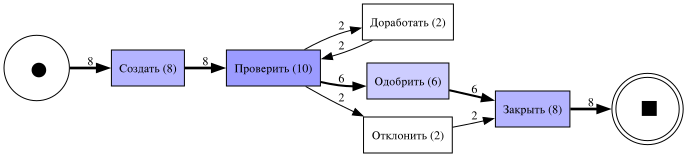

In [25]:
if HAS_DOT:
    from pm4py.visualization.dfg import visualizer as dfg_visualizer

    dfg_graph = dfg_visualizer.apply(
        dfg,
        parameters={
            "start_activities": start_activities,
            "end_activities": end_activities,
        },
    )
    display(SVG(dfg_graph.pipe(format="svg")))
else:
    print("Установите системный Graphviz для рисунка DFG; таблица рёбер приведена выше.")

### Сколько времени проходит между действиями

**Функция: `pm4py.discover_performance_dfg`**

```python
performance_dfg, start_activities, end_activities = pm4py.discover_performance_dfg(log)
```

Принимает журнал и для каждой пары соседних действий собирает статистику
временных интервалов. Возвращает граф с этой статистикой, а также частоты
начальных и конечных действий.

Чтобы получить средний интервал в часах, нужно взять значение поля `mean`
в секундах и разделить на 3600. Так можно найти участки с долгими паузами.
Пауза может включать и работу, и ожидание: по одним отметкам событий их не разделить.

In [26]:
performance_dfg, _, _ = pm4py.discover_performance_dfg(log)
performance_table = pd.DataFrame([
    {"Из": source, "В": target, "Средний интервал, ч": stats["mean"] / 3600}
    for (source, target), stats in performance_dfg.items()
]).sort_values("Средний интервал, ч", ascending=False).reset_index(drop=True)
performance_table.round(2)

,Из,В,"Средний интервал, ч"
0,Проверить,Доработать,3.00
1,Доработать,Проверить,2.50
2,Одобрить,Закрыть,2.50
3,Создать,Проверить,1.62
4,Отклонить,Закрыть,1.50
5,Проверить,Одобрить,1.50
6,Проверить,Отклонить,1.00


## 6. Discovery: построение сети Петри

Теперь нужно построить модель, по которой можно воспроизводить трассы.
Для этого можно использовать Inductive Miner: он выделяет в журнале последовательности действий,
развилки, параллельные ветки и циклы.

**Функция: `pm4py.discover_petri_net_inductive`**

```python
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log, noise_threshold=0.0)
```

Принимает журнал и возвращает сеть Петри `net`, начальную маркировку `initial_marking`
и конечную маркировку `final_marking`. Маркировка описывает расположение фишек по местам.
Она задаёт, откуда начинается выполнение и какое состояние считается завершением.

Параметр `noise_threshold` управляет фильтрацией шума при построении модели.
Значение `0.0` отключает эту фильтрацию: в учебном примере нужно учесть и редкие маршруты.

Как читать рисунок:

- Пустой круг или овал обозначает место, в котором могут находиться фишки.
- Чёрная точка внутри места обозначает фишку.
- Белый прямоугольник с подписью обозначает действие из журнала.
- Чёрный прямоугольник обозначает служебный переход без события в журнале.
  Он нужен для структуры сети, например для выхода из цикла или пропуска ветки.
  В PM4Py у такого перехода `label is None`.

Найденная модель может разрешать и маршруты, которых не было в исходных данных.
Сама сеть не задаёт вероятности выбора веток и длительности действий.

**Функция для рисунка: `pn_visualizer.apply`**

```python
pn_visualizer.apply(net, initial_marking, final_marking)
```

Это `apply` из модуля `pm4py.visualization.petri_net.visualizer`. Ниже потребуется
импортировать этот модуль под именем `pn_visualizer`. Функция принимает готовую сеть и маркировки,
возвращает объект Graphviz для рисунка. Затем `.pipe(format="svg")` создаёт SVG,
а `display` показывает его в ноутбуке.

Мест: 6
Переходов: 7
Видимые действия: ['Доработать', 'Закрыть', 'Одобрить', 'Отклонить', 'Проверить', 'Создать']


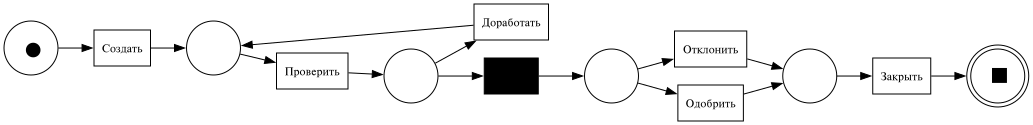

In [27]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    log, noise_threshold=0.0
)
print("Мест:", len(net.places))
print("Переходов:", len(net.transitions))
print("Видимые действия:", sorted({t.label for t in net.transitions if t.label is not None}))

if HAS_DOT:
    from pm4py.visualization.petri_net import visualizer as pn_visualizer

    net_graph = pn_visualizer.apply(net, initial_marking, final_marking)
    display(SVG(net_graph.pipe(format="svg")))
else:
    print("Установите системный Graphviz для рисунка сети Петри.")

## 7. Conformance checking: проверка соответствия модели

На этапе discovery удалось получить сеть из журнала. Теперь нужно зафиксировать её
и проверить, можно ли по ней воспроизвести записанные действия.
Для этого можно использовать token-based replay: алгоритм проводит фишки по сети
в порядке событий трассы и учитывает недостающие и оставшиеся фишки.

**Функция: `pm4py.fitness_token_based_replay`**

```python
pm4py.fitness_token_based_replay(log, net, initial_marking, final_marking)
```

Принимает журнал, сеть и две маркировки. Возвращает словарь с оценками соответствия
для всего журнала. В первую очередь стоит обратить внимание на два поля:

- `log_fitness`: общая оценка воспроизведения от 0 до 1, где 1 означает полное соответствие
  по этой метрике;
- `percentage_of_fitting_traces`: процент трасс, которые удалось воспроизвести полностью.

Сначала нужно передать тот же журнал, по которому была построена сеть. Здесь можно ожидать высокий fitness.
Это полезная проверка примера, но для оценки модели нужны и новые трассы.
Кроме fitness существует precision: она оценивает, насколько много поведения
модель разрешает сверх наблюдаемого в журнале. В этом ноутбуке расчёт precision не предусмотрен.

In [28]:
fitness = pm4py.fitness_token_based_replay(log, net, initial_marking, final_marking)
display(pd.Series(fitness, name="Значение").to_frame())

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

,Значение
perc_fit_traces,100.0
average_trace_fitness,1.0
log_fitness,1.0
percentage_of_fitting_traces,100.0


### Проверка двух новых заявок

Для `NEW_OK` нужно задать обычный маршрут, а для `NEW_SKIP` пропустить проверку перед одобрением.
Модель следует оставить прежней, иначе новая трасса могла бы повлиять на то, что она разрешает.

**Функция: `pm4py.convert_to_event_log`**

```python
new_traces = pm4py.convert_to_event_log(new_log)
```

Преобразует DataFrame в объект `EventLog`, в котором события сгруппированы по трассам.
Здесь это удобно, чтобы сопоставить результат проверки с идентификатором каждой заявки.

**Функция: `pm4py.conformance_diagnostics_token_based_replay`**

```python
pm4py.conformance_diagnostics_token_based_replay(new_traces, net, initial_marking, final_marking)
```

Принимает журнал, сеть и маркировки. В используемом здесь режиме возвращает список
результатов replay по трассам в порядке входного `EventLog`.
В отличие от общей оценки fitness, позволяет разобрать каждую заявку отдельно.

В таблицу нужно вывести три поля:

- `trace_is_fit`: удалось ли полностью воспроизвести трассу;
- `missing_tokens`: сколько фишек недоставало при воспроизведении;
- `remaining_tokens`: сколько лишних фишек осталось после него.

Для `NEW_OK` должно получиться соответствие, а для `NEW_SKIP` отклонение.
Количество проблемных фишек зависит от структуры сети. Чтобы понять причину
отклонения в реальном процессе, нужно также посмотреть на саму трассу и контекст заявки.

In [29]:
new_rows = []
for case_id, activities in [
    ("NEW_OK", normal),
    ("NEW_SKIP", ["Создать", "Одобрить", "Закрыть"]),
]:
    for hour, activity in enumerate(activities):
        new_rows.append({
            "case_id": case_id,
            "activity": activity,
            "timestamp": pd.Timestamp("2026-02-01 09:00:00", tz="UTC") + pd.Timedelta(hours=hour),
        })

new_log = pm4py.format_dataframe(
    pd.DataFrame(new_rows),
    case_id="case_id",
    activity_key="activity",
    timestamp_key="timestamp",
)
# EventLog явно задаёт порядок трасс, чтобы сопоставить диагностику с case_id.
new_traces = pm4py.convert_to_event_log(new_log)
replay = pm4py.conformance_diagnostics_token_based_replay(
    new_traces, net, initial_marking, final_marking
)
diagnostics = pd.DataFrame([
    {
        "case_id": trace.attributes["concept:name"],
        "trace_is_fit": result["trace_is_fit"],
        "missing_tokens": result["missing_tokens"],
        "remaining_tokens": result["remaining_tokens"],
    }
    for trace, result in zip(new_traces, replay)
]).set_index("case_id")

display(diagnostics)
assert diagnostics.loc["NEW_OK", "trace_is_fit"]
assert not diagnostics.loc["NEW_SKIP", "trace_is_fit"]

replaying log with TBR, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

,trace_is_fit,missing_tokens,remaining_tokens
case_id,,,
NEW_OK,True,0,0
NEW_SKIP,False,1,1


## 8. Обмен данными: XES и CSV

XES используют для обмена журналами событий между инструментами process mining.
Для проверки обмена данными нужно сохранить журнал в этом формате и прочитать обратно.

**Функция: `pm4py.write_xes`**

```python
pm4py.write_xes(log, str(xes_path))
```

Принимает журнал и путь, записывает XES-файл на диск.
В примере достаточно использовать временный каталог, который удалится после чтения файла.

**Функция: `pm4py.read_xes`**

```python
pm4py.read_xes(str(xes_path), return_legacy_log_object=False)
```

Читает XES-файл по указанному пути. С параметром `return_legacy_log_object=False`
возвращает DataFrame. Для проверки сохранности журнала нужно сравнить ключевые поля событий до записи и после чтения.

In [30]:
with TemporaryDirectory(prefix="pm4py_intro_") as temp_dir:
    xes_path = Path(temp_dir) / "requests.xes"
    pm4py.write_xes(log, str(xes_path))
    restored = pm4py.read_xes(str(xes_path), return_legacy_log_object=False)

columns = [CASE, ACTIVITY, TIME]
expected = log[columns].sort_values([CASE, TIME]).reset_index(drop=True)
actual = restored[columns].sort_values([CASE, TIME]).reset_index(drop=True)
# XES / pandas могут восстановить другую точность datetime или строковый dtype.
pd.testing.assert_frame_equal(expected, actual, check_dtype=False)
print(f"XES: восстановлено {len(restored)} событий и {restored[CASE].nunique()} кейсов.")

exporting log, completed traces ::   0%|          | 0/8 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/8 [00:00<?, ?it/s]

XES: восстановлено 36 событий и 8 кейсов.


### Как подставить свой CSV

Ниже оставлен шаблон: замените путь и названия столбцов, затем раскомментируйте строки.
`pd.read_csv` читает таблицу, а `pd.to_datetime` разбирает время.
После этого знакомые `pm4py.format_dataframe` и `pm4py.discover_dfg`
подготовят журнал и построят граф.

Идентификатор кейса нужно читать как строку, чтобы, например, номер `001` не превратился в `1`.
Параметр `utc=True` подходит, если время уже задано в UTC или содержит смещение.
Для местного времени без смещения сначала укажите исходный часовой пояс.

In [31]:
# Шаблон для своего CSV: укажите путь и реальные названия столбцов.
# my_raw = pd.read_csv("events.csv", dtype={"case_id": str})
# my_raw["timestamp"] = pd.to_datetime(my_raw["timestamp"], utc=True)
# my_log = pm4py.format_dataframe(
#     my_raw, case_id="case_id", activity_key="activity", timestamp_key="timestamp"
# )
# my_dfg, my_starts, my_ends = pm4py.discover_dfg(my_log)

## 9. Что можно попробовать?

1. Добавьте в `cases` заявку с двумя доработками и запустите ноутбук заново.
   Что изменилось в вариантах трасс, частотах рёбер и модели?
2. Выберите целиком кейсы с действием «Отклонить». Сравните их длительности с остальными.
3. Сравните фильтрацию с `level="case"` и `level="event"`.
   Почему для полученных журналов строятся разные графы?
4. Добавьте новую тестовую трассу с повторной проверкой без доработки.
   Сначала предположите, разрешает ли её модель, затем выполните replay.

### Связь с SurvivalProcessMining

В этом примере все заявки завершены. В реальном журнале история заявки может
оборваться просто потому, что закончился период наблюдения.
Последнее записанное событие в таком случае не означает завершение процесса.

Для survival analysis нужно заранее определить целевое событие, конец периода
наблюдения и признак цензурирования. Это позволит различать завершённые заявки
и те, за которыми перестали наблюдать.

### Где читать дальше

- [PM4Py: исходный код и примеры](https://github.com/process-intelligence-solutions/pm4py)
- [Документация PM4Py](https://processintelligence.solutions/pm4py/)

## 10. Все функции PM4Py из ноутбука

В таблице собраны все функции PM4Py, использованные в ноутбуке. Названия `dfg_visualizer`
и `pn_visualizer` обозначают импортированные модули визуализации PM4Py.

| Функция | Входные данные | Что делает или возвращает |
|---|---|---|
| `pm4py.format_dataframe` | Таблицу и названия столбцов кейса, действия и времени | Готовит DataFrame со стандартными полями PM4Py |
| `pm4py.get_start_activities` | Журнал | Возвращает первые действия кейсов и их частоты |
| `pm4py.get_end_activities` | Журнал | Возвращает последние действия кейсов и их частоты |
| `pm4py.get_variants_as_tuples` | Журнал | Возвращает варианты трасс в виде кортежей и число кейсов каждого варианта |
| `pm4py.filter_event_attribute_values` | Журнал, атрибут, значения и уровень фильтрации | Отбирает или исключает события либо кейсы целиком |
| `pm4py.discover_dfg` | Журнал | Возвращает частоты соседних пар действий, начальных и конечных действий |
| `dfg_visualizer.apply` | DFG и параметры отображения | Создаёт объект Graphviz для рисунка DFG |
| `pm4py.discover_performance_dfg` | Журнал | Возвращает статистику времени между соседними действиями и частоты начала и конца |
| `pm4py.discover_petri_net_inductive` | Журнал и порог фильтрации шума | Строит сеть Петри и возвращает её с начальной и конечной маркировками |
| `pn_visualizer.apply` | Сеть Петри и маркировки | Создаёт объект Graphviz для рисунка сети |
| `pm4py.fitness_token_based_replay` | Журнал, сеть Петри и маркировки | Возвращает общие оценки соответствия журнала модели |
| `pm4py.convert_to_event_log` | Таблицу событий | Преобразует её в EventLog с отдельными трассами |
| `pm4py.conformance_diagnostics_token_based_replay` | Журнал, сеть Петри и маркировки | Возвращает диагностику воспроизведения каждой трассы |
| `pm4py.write_xes` | Журнал и путь к файлу | Записывает журнал в XES |
| `pm4py.read_xes` | Путь к XES-файлу и параметры чтения | Читает журнал; в этом примере возвращает DataFrame |